In [9]:
%pip install arch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

from arch.univariate.base import DataScaleWarning
from arch.utility.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
import itertools
import math

In [11]:
tickers=[
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "ICICIBANK.NS", "HINDUNILVR.NS",
    "ITC.NS", "KOTAKBANK.NS", "LT.NS", "SBIN.NS", "AXISBANK.NS", "BAJFINANCE.NS",
    "BHARTIARTL.NS", "ASIANPAINT.NS", "HCLTECH.NS", "MARUTI.NS", "SUNPHARMA.NS", "TITAN.NS",
    "ULTRACEMCO.NS", "WIPRO.NS", "TECHM.NS", "NESTLEIND.NS", "POWERGRID.NS", "NTPC.NS",
    "JSWSTEEL.NS", "TATASTEEL.NS", "BAJAJFINSV.NS", "ADANIENT.NS", "ADANIPORTS.NS", "HINDALCO.NS",
    "ONGC.NS", "COALINDIA.NS", "EICHERMOT.NS", "HDFCLIFE.NS", "SBILIFE.NS", "BRITANNIA.NS",
    "DIVISLAB.NS", "CIPLA.NS", "GRASIM.NS", "BPCL.NS", "IOC.NS", "HEROMOTOCO.NS",
    "BAJAJ-AUTO.NS", "SHREECEM.NS", "DRREDDY.NS", "M&M.NS", "INDUSINDBK.NS", "APOLLOHOSP.NS"
]

In [12]:
%pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
from arch import arch_model
from tqdm import tqdm  #progress bar

In [14]:
avg_forecasted_vol=[]

start_date='2022-03-01'
end_date='2024-05-31'

data=yf.download(tickers,start=start_date,end=end_date,interval="1d")
returns=data["Close"].pct_change().dropna()
returns=returns*100

[*********************100%***********************]  48 of 48 completed


In [15]:
returns

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,BPCL.NS,...,SBILIFE.NS,SBIN.NS,SHREECEM.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-03,0.121821,-0.506825,1.163277,-5.184975,-1.679440,-2.229935,-2.173430,-1.217880,-0.326300,1.256942,...,-3.554390,-1.444380,-4.619629,0.000000,1.081945,-0.049341,2.316491,-0.709697,-6.542062,2.584643
2022-03-04,-1.752037,-0.926849,-3.468017,-4.657179,-3.070565,-1.668129,-2.361813,-3.118536,-2.730445,0.562935,...,-2.214924,-1.166020,-1.212157,1.065902,-2.010293,-0.565691,1.889047,-5.176253,1.163724,1.009576
2022-03-07,-3.154808,-3.192185,-1.746261,-1.084705,-6.636361,-0.229792,-6.260933,-6.315494,3.319570,-2.971153,...,-2.690691,-4.686665,-2.483350,-0.843727,1.158876,-1.119336,-2.029440,-2.101608,-5.821187,-0.599696
2022-03-08,2.400823,1.630272,1.241328,0.551992,0.426941,2.548966,0.539199,0.601635,1.125256,1.065096,...,0.296438,0.000000,2.698921,3.932422,-1.733884,3.301356,2.657820,-0.772060,2.375351,2.728009
2022-03-09,3.430946,3.665547,-0.239307,5.564723,0.566823,0.660211,3.906392,5.041516,1.244500,0.307366,...,-0.654105,2.589155,-2.741774,1.549703,-1.114606,0.906968,2.927594,2.631516,3.152509,-0.331960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-24,-0.069371,-1.887971,-0.932985,-0.998714,0.750906,-0.170140,-0.419657,0.150163,1.051641,1.027099,...,-0.729198,-0.420623,-0.858560,-0.561835,-0.370371,-1.128812,-1.177570,-1.148600,0.595352,-0.461572
2024-05-27,-2.833137,1.098090,0.421851,-0.085225,1.107325,0.564360,-0.368345,0.857097,-0.298892,0.298134,...,-1.813755,0.615502,-0.162039,-1.388977,0.371748,-0.063640,0.601480,-0.263740,-0.054738,-2.415612
2024-05-28,-1.368166,-2.175809,-0.585915,1.354315,-0.303283,-0.099468,0.241259,-0.325567,-0.960735,-1.455694,...,2.875485,-0.305861,0.863464,-0.078441,-0.341885,-0.185873,-1.097995,0.176292,-0.455711,0.795666


In [16]:
warnings.filterwarnings("ignore")

In [ ]:
vol_forecast_dict = {}
avg_forecasted_vol_list=[]
for ticker in tqdm(tickers):
    window_size = 90
    forecast_horizon = 1  #one day ahead
    rolling_volatility = []
    dates = []
    
    for i in range(window_size, len(returns)):
        train_data = returns[ticker].iloc[i-window_size:i]   
        
        if train_data.isna().any() or train_data.std() < 1e-6:
            continue  # skip bad segments
    
        model = arch_model(train_data, vol='EGARCH', p=1, q=1, o=1, dist='t')
        
        try:
            result = model.fit(disp='off', options={"maxiter": 5000},show_warning=False)
            forecast = result.forecast(horizon=forecast_horizon)
            var = forecast.variance.values[-1, 0]
            
            if not np.isnan(var) and var < 10000:
                vol = np.sqrt(var) /100   # divide because train_data was scaled
                rolling_volatility.append(vol)
                dates.append(returns.index[i])
        except Exception as e:
            continue
    
    vol_series = pd.Series(rolling_volatility, index=dates)
    vol_forecast_dict[ticker]=vol_series
    
    avg_forecasted_vol=np.mean(rolling_volatility)
    avg_forecasted_vol_list.append(avg_forecasted_vol)
    print("avg_forecasted_vol of "+str(ticker)+" = "+str(avg_forecasted_vol))


vol_forecast_df = pd.DataFrame(vol_forecast_dict)    
avg_forecasted_vol_df=pd.DataFrame(avg_forecasted_vol_list,index=tickers)

  2%|▏         | 1/48 [00:38<30:08, 38.49s/it]

avg_forecasted_vol of RELIANCE.NS = 0.038638186652805155


  4%|▍         | 2/48 [01:12<27:36, 36.02s/it]

avg_forecasted_vol of TCS.NS = 0.024932874127804833


  6%|▋         | 3/48 [01:41<24:30, 32.68s/it]

...

avg_forecasted_vol of ITC.NS = 0.03647374051187733


 17%|█▋        | 8/48 [05:03<24:49, 37.24s/it]

avg_forecasted_vol of KOTAKBANK.NS = 0.06530897722041774


 19%|█▉        | 9/48 [05:36<23:22, 35.97s/it]

avg_forecasted_vol of LT.NS = 0.04475779465092055


In [ ]:
##### avg_forecasted_vol_df=avg_forecasted_vol_df.sort_index()
avg_forecasted_vol_df

NameError: name 'avg_forecasted_vol_df' is not defined

In [ ]:
closing_data=yf.download(tickers,start=start_date,end=end_date,interval="1d")
closing_data=closing_data["Close"]
log_returns=np.log(closing_data/closing_data.shift(1))
expected_returns=log_returns.mean()
expected_returns_df=pd.DataFrame(expected_returns,columns=["expected returns"],index=tickers)
expected_returns
print(tickers)

[*********************100%***********************]  48 of 48 completed

['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'HINDUNILVR.NS', 'ITC.NS', 'KOTAKBANK.NS', 'LT.NS', 'SBIN.NS', 'AXISBANK.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'ASIANPAINT.NS', 'HCLTECH.NS', 'MARUTI.NS', 'SUNPHARMA.NS', 'TITAN.NS', 'ULTRACEMCO.NS', 'WIPRO.NS', 'TECHM.NS', 'NESTLEIND.NS', 'POWERGRID.NS', 'NTPC.NS', 'JSWSTEEL.NS', 'TATASTEEL.NS', 'BAJAJFINSV.NS', 'ADANIENT.NS', 'ADANIPORTS.NS', 'HINDALCO.NS', 'ONGC.NS', 'COALINDIA.NS', 'EICHERMOT.NS', 'HDFCLIFE.NS', 'SBILIFE.NS', 'BRITANNIA.NS', 'DIVISLAB.NS', 'CIPLA.NS', 'GRASIM.NS', 'BPCL.NS', 'IOC.NS', 'HEROMOTOCO.NS', 'BAJAJ-AUTO.NS', 'SHREECEM.NS', 'DRREDDY.NS', 'M&M.NS', 'INDUSINDBK.NS', 'APOLLOHOSP.NS']


In [ ]:
scores=[]
r=0.5 #Risk Aversion Coefficient
i=0
while i<len(expected_returns):
    score=((1-r)*expected_returns.iloc[i])-(r*avg_forecasted_vol_df.iloc[i])
    scores.append(score)
    i+=1
score_df=pd.DataFrame(scores,index=expected_returns.index)
score_df.columns=["Score"]
#sorting the score_df according to the max score and showing the top 2 stocks
score_df.sort_values('Score', inplace=True,ascending=False)
score_df.head(2)

,Score
Ticker,
GRASIM.NS,-0.008723
BRITANNIA.NS,-0.011240


In [ ]:
stock_1=score_df.index[0]
stock_2=score_df.index[1]

In [ ]:
stock_1_df=yf.download(stock_1,start="2024-06-01",end="2025-06-01",interval="1d",multi_level_index=False)
stock_2_df=yf.download(stock_2,start="2024-06-01",end="2025-06-01",interval="1d",multi_level_index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
capital=100000

In [ ]:
def df_update(df):
    df.reset_index(inplace=True)
    df.columns = df.columns.get_level_values(0)
    
    
    df["EMA_14"]=df["Close"].ewm(span=14,adjust=False).mean()
    df["buy_band"]=df["EMA_14"]+df["High"]-df["Low"]
    df["sell_band"]=df["EMA_14"]-df["High"]+df["Low"]
    
df_update(stock_1_df)
df_update(stock_2_df)

In [ ]:
stock_1_df

,Date,Close,High,Low,Open,Volume,EMA_14,buy_band,sell_band
0,2024-06-03,2351.178711,2387.307837,2344.727064,2382.146568,807692,2351.178711,2393.759484,2308.597938
1,2024-06-04,2239.614990,2347.605697,2155.445995,2318.672635,1543389,2336.303548,2528.463251,2144.143846
2,2024-06-05,2287.704590,2296.538287,2165.917147,2241.599932,1996915,2329.823687,2460.444827,2199.202547
3,2024-06-06,2317.382080,2335.496321,2276.042006,2288.895624,834320,2328.164806,2387.619120,2268.710492
4,2024-06-07,2362.146729,2365.719803,2294.007261,2294.007261,471524,2332.695729,2404.408272,2260.983187
...,...,...,...,...,...,...,...,...,...
242,2025-05-26,2646.771484,2686.825970,2630.530760,2662.813225,435977,2696.342923,2752.638132,2640.047713
243,2025-05-27,2604.724365,2648.764107,2585.594007,2646.372903,874537,2684.127115,2747.297214,2620.957016
244,2025-05-28,2568.257324,2611.300693,2560.784509,2611.300693,849149,2668.677810,2719.193994,2618.161625
245,2025-05-29,2564.271729,2584.497954,2542.949150,2568.257230,616258,2654.756999,2696.305803,2613.208195


In [ ]:
def strategy(df):
    signal=[0]
    for i in range(1,len(df)):
        if df.loc[i,"Close"]>df.loc[i,"buy_band"] and df.loc[i-1,"Close"]<=df.loc[i-1,"buy_band"]:
            signal.append(1)
        elif df.loc[i,"Close"]<df.loc[i,"sell_band"] and df.loc[i-1,"Close"]>=df.loc[i-1,"sell_band"]:
            signal.append(-1)
        else:
            signal.append(0)
    df["Signal"]=signal



strategy(stock_1_df)
strategy(stock_2_df)

In [ ]:
def backtesting(df,signal,initial_capital):
    trade_idx=[]
    opening_trade_idx=[]
    closing_trade_idx=[]
    entry_date=[]
    exit_date=[]
    pos=[]
    type_of_trade=[]

    prev_pos=0
    current_signal=0
    for i in range(len(df)):
        if df.loc[i,signal]==1 or df.loc[i,signal]==-1:
            trade_idx.append(i)
        
        current_signal=df.loc[i,signal]
        
        if current_signal==1:
            if prev_pos==0:
                pos.append(1)
                opening_trade_idx.append(i)
                type_of_trade.append("long")
                entry_date.append(df.loc[i,"Date"])
            elif prev_pos==1:
                pos.append(1)
            elif prev_pos==-1:
                pos.append(0)
                closing_trade_idx.append(i)
                exit_date.append(df.loc[i,"Date"])
        elif current_signal==-1:
            if prev_pos==0:
                pos.append(-1)
                opening_trade_idx.append(i)
                type_of_trade.append("short")
                entry_date.append(df.loc[i,"Date"])
            elif prev_pos==1:
                pos.append(0)
                closing_trade_idx.append(i)
                exit_date.append(df.loc[i,"Date"])
            elif prev_pos==-1:
                pos.append(-1)
        else:
            pos.append(prev_pos)

        prev_pos=pos[i]

    #squaring off all positions at the end
    if pos[len(df)-1]==1:
        pos[len(df)-1]=0
        df.loc[len(df)-1,signal]=-1
        closing_trade_idx.append(len(df)-1)
        exit_date.append(df.loc[len(df)-1,"Date"])
    elif pos[len(df)-1]==-1:
        pos[len(df)-1]=0
        df.loc[len(df)-1,signal]=1
        closing_trade_idx.append(len(df)-1)
        exit_date.append(df.loc[len(df)-1,"Date"])
        
    

    no_of_shares=[]
    capital=initial_capital
    portfolio=[]
    shares=0

    for i in range(len(df)):
        price=df.loc[i,"Close"]
        #long trade
        if df.loc[i,signal]==1 and pos[i-1]==0 and capital>price :
            shares=int(capital/price)
            capital-=shares*price
            #trades_idx_1.append(i)
            #type_of_trade1.append("long")
        elif df.loc[i,signal]==-1 and pos[i-1]==1 and shares>0:
            capital+=shares*price
            shares=0
            #trades_idx_1.append(i)
            #type_of_trade1.append("long close")
        #short trade    
        elif df.loc[i,signal]==-1 and pos[i-1]==0 and capital>price:
            shares=-int(capital/price)
            capital-=shares*price
            #trades_idx_1.append(i)
            #type_of_trade1.append("short")
        elif df.loc[i,signal]==1 and pos[i-1]==-1 and shares<0:
            capital+=shares*price
            shares=0
            #trades_idx_1.append(i)
            #type_of_trade1.append("short close")
        portfolio_value=shares*price+capital
        portfolio.append(portfolio_value)
        no_of_shares.append(shares)

    #print((opening_trade_idx))
    #print((closing_trade_idx))
    #print(len(type_of_trade))
    #print(pos)
    #print(type_of_trade)
    #print(df.loc[len(df)-1,signal])
    
    
    returns=[]
    for i in range(len(opening_trade_idx)):
        if type_of_trade[i]=="long":
            returns.append((df.loc[closing_trade_idx[i],"Close"]-df.loc[opening_trade_idx[i],"Close"])*100/df.loc[opening_trade_idx[i],"Close"])
        else:
            returns.append(-(df.loc[closing_trade_idx[i],"Close"]-df.loc[opening_trade_idx[i],"Close"])*100/df.loc[opening_trade_idx[i],"Close"])
        
        
    
    trade_wise_df=pd.DataFrame({"Entry Index": opening_trade_idx,"Exit Index":closing_trade_idx,"Entry Date":entry_date,"Exit Date":exit_date,"Type of Trade":type_of_trade})
    trade_wise_df["No of stock traded"]=[no_of_shares[i]-no_of_shares[i-1] for i in opening_trade_idx]
    trade_wise_df["Return for trade in %"]=returns
    trade_wise_df["Trade Duration"]=trade_wise_df["Exit Index"]-trade_wise_df["Entry Index"]
    #np.where(df_1["Type of trade"]=='long',(returns,-returns)
    
    daily_df=pd.DataFrame({"Portfolio Value":portfolio,"No. of Stock":no_of_shares})
    daily_df["Profit from initial Capital"]=(daily_df["Portfolio Value"]-initial_capital)*100/initial_capital
    daily_df["Daily Returns in %"]=(daily_df["Portfolio Value"].pct_change())*100
    return trade_wise_df,daily_df

trade_wise_stock_1,daily_stock_1=backtesting(stock_1_df,"Signal",capital/2)
trade_wise_stock_2,daily_stock_2=backtesting(stock_2_df,"Signal",capital/2)

In [ ]:
def plot_buy_sell(df,trade_wise_df):
    import plotly.graph_objects as go

    fig = go.Figure()
    
    # Line plot for stock price
    fig.add_trace(go.Scatter(
        x=df["Date"],
        y=df["Close"],
        mode='lines',
        name='Close Price',
        line=dict(color='blue')
    ))
    

    long_trades = trade_wise_df[trade_wise_df["Type of Trade"] == "long"]
    short_trades = trade_wise_df[trade_wise_df["Type of Trade"] == "short"]
    
    # Long Entry: green triangle-up
    fig.add_trace(go.Scatter(
        x=df.loc[long_trades["Entry Index"], "Date"],
        y=df.loc[long_trades["Entry Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-up', color='green', size=12),
        name='Long Entry'
    ))
    
    # Short Entry: red triangle-down
    fig.add_trace(go.Scatter(
        x=df.loc[short_trades["Entry Index"], "Date"],
        y=df.loc[short_trades["Entry Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-down', color='red', size=12),
        name='Short Entry'
    ))
    
    # Long Exit: red triangle-down
    fig.add_trace(go.Scatter(
        x=df.loc[long_trades["Exit Index"], "Date"],
        y=df.loc[long_trades["Exit Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-down', color='red', size=10),
        name='Long Exit'
    ))
    
    # Short Exit: green triangle-up
    fig.add_trace(go.Scatter(
        x=df.loc[short_trades["Exit Index"], "Date"],
        y=df.loc[short_trades["Exit Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-up', color='green', size=10),
        name='Short Exit'
    ))
    
    fig.update_layout(title="Trade Entries & Exits on Stock Price")
    fig.show()

def plot_portfolio(df,daily_df):
    fig=px.line(x=df["Date"],y=daily_df["Portfolio Value"])
    fig.show()


In [ ]:
pip install --upgrade nbformat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
plot_buy_sell(stock_1_df,trade_wise_stock_1)

NameError: name 'stock_1_df' is not defined

In [ ]:
plot_buy_sell(stock_2_df,trade_wise_stock_2)

NameError: name 'stock_2_df' is not defined

In [ ]:
def benchmark_metrics(df,trade_wise_df,daily_df):
    benchmark_return=((df.loc[len(df)-1,"Close"]-df.loc[0,"Close"])*100)/df.loc[0,"Close"]
    gross_profit=daily_df.loc[len(daily_df)-1,"Profit from initial Capital"]

    total_trades=len(trade_wise_df)
    winning_trades= (trade_wise_df["Return for trade in %"]>0).sum()
    losing_trades=total_trades-winning_trades
    max_holding_time=trade_wise_df["Trade Duration"].max()
    avg_holding_time=trade_wise_df["Trade Duration"].mean()

    #to calculate max drawdown
    drawdown=[]
    for i in range(len(trade_wise_df)):
        entry_idx=trade_wise_df.loc[i,"Entry Index"]
        exit_idx=trade_wise_df.loc[i,"Exit Index"]
        initial_value=daily_df.loc[entry_idx,"Portfolio Value"]

        max_drawdown=0
        temp1=initial_value
        for j in range(entry_idx+1,exit_idx+1):
            temp1=max(temp1,daily_df.loc[j,"Portfolio Value"])
            drawdown_value = (temp1 - daily_df.loc[j,"Portfolio Value"]) / temp1
            max_drawdown=max(max_drawdown,drawdown_value)
        drawdown.append(max_drawdown)

    mean_return=trade_wise_df["Return for trade in %"].mean()
    std_return=trade_wise_df["Return for trade in %"].std()
    rfr=0
    sharpe=(mean_return-rfr)*np.sqrt(252)/std_return
    
    mean_return_daily=daily_df["Daily Returns in %"].mean()
    std_return_daily=daily_df["Daily Returns in %"].std()
    sharpe_daily=mean_return_daily-rfr*np.sqrt(252)/std_return_daily
    
    

    print("Benchmark Return: "+str(benchmark_return)+" %")
    print("Gross Profit: "+str(gross_profit)+" %")
    print("Max Holding Time: "+str(max_holding_time))
    print("Average Holding Time: "+str(avg_holding_time))
    print("Total Trades: "+str(total_trades))
    print("Winning Trades: "+str(winning_trades))
    print("Losing Trades: "+str(losing_trades))
    print("Max Drawdown: "+str(100*max(drawdown))+" %")
    print("Sharpe Ratio: "+str(sharpe))
    
    final_value=(1+(gross_profit/100))*capital/2
    return (final_value)

In [ ]:
final_value_stock_1=benchmark_metrics(stock_1_df,trade_wise_stock_1,daily_stock_1)

Benchmark Return: 7.885137823727412 %
Gross Profit: 8.42212890625 %
Max Holding Time: 36
Average Holding Time: 22.375
Total Trades: 8
Winning Trades: 4
Losing Trades: 4
Max Drawdown: 7.627206531303036 %
Sharpe Ratio: 2.991471978242604


In [ ]:
final_value_stock_2=benchmark_metrics(stock_2_df,trade_wise_stock_2,daily_stock_2)

Benchmark Return: 14.672877934971485 %
Gross Profit: 14.473858520507813 %
Max Holding Time: 88
Average Holding Time: 33.0
Total Trades: 6
Winning Trades: 3
Losing Trades: 3
Max Drawdown: 11.734149315119321 %
Sharpe Ratio: 4.906064606927207


In [ ]:
nifty_50=yf.download(tickers,start="2024-06-01",end="2025-06-01",interval="1d")

[*********************100%***********************]  48 of 48 completed


In [ ]:
nifty_50=nifty_50["Close"]

In [ ]:
capital=100000
capital_per_stock=capital/48 #out of 50 -2 stocks data could not be retrieved from yfinance
capital_retained=0
for stock in nifty_50:
    shares=capital_per_stock/nifty_50.loc[nifty_50.index[0],stock]
    capital_retained+=shares*nifty_50.loc[nifty_50.index[-1],stock]

R_market=((capital_retained-capital)/capital)*100
print(f"R-Market= {R_market} %")

R-Market= 5.906997617518093 %


In [ ]:
R_user=((final_value_stock_1+final_value_stock_2)-capital)*100/capital
print(f"R-User= {R_user} %")

R-User= 11.447993713378906 %


In [ ]:
user_score=R_user*100/R_market
print(f"User Score= {user_score} %")

User Score= 193.80393314241658 %


In [ ]:
correlations1=log_returns.corrwith(log_returns[stock_1])
correlations2=log_returns.corrwith(log_returns[stock_2])
correlations1.sort_values(inplace=True,ascending=False)
correlations2.sort_values(inplace=True,ascending=False)

hedge_stock1=correlations1.index[1]
hedge_stock2=correlations2.index[1]
print(hedge_stock1)
print(hedge_stock2)

ULTRACEMCO.NS
INFY.NS


In [ ]:
correlations1

Ticker
GRASIM.NS        1.000000
ULTRACEMCO.NS    0.600834
SBIN.NS          0.435833
JSWSTEEL.NS      0.431109
BAJAJFINSV.NS    0.424664
SHREECEM.NS      0.421766
ICICIBANK.NS     0.398815
HINDALCO.NS      0.398059
TITAN.NS         0.387272
BAJFINANCE.NS    0.387221
TATASTEEL.NS     0.384516
AXISBANK.NS      0.354286
LT.NS            0.354212
ASIANPAINT.NS    0.350638
M&M.NS           0.350375
ADANIPORTS.NS    0.347059
INDUSINDBK.NS    0.340049
SBILIFE.NS       0.334028
EICHERMOT.NS     0.321718
RELIANCE.NS      0.321593
HDFCBANK.NS      0.316050
NESTLEIND.NS     0.309488
MARUTI.NS        0.300493
APOLLOHOSP.NS    0.295123
HDFCLIFE.NS      0.293985
NTPC.NS          0.289047
BPCL.NS          0.288081
WIPRO.NS         0.285638
HINDUNILVR.NS    0.283949
HEROMOTOCO.NS    0.275860
ITC.NS           0.274184
ADANIENT.NS      0.270358
BRITANNIA.NS     0.264733
BHARTIARTL.NS    0.264679
KOTAKBANK.NS     0.262199
TCS.NS           0.249800
TECHM.NS         0.246158
DIVISLAB.NS      0.240430
COALI

In [ ]:
stock1 = stock_1
stock2 = stock_2

tickers = [stock1,stock2,hedge_stock1,hedge_stock2]
df = yf.download(tickers,start='2022-03-01',end='2024-05-31')['Close']

#changes

for ticker in tickers:
  stock1_df=yf.download(stock1,start='2022-03-01',end='2024-05-31')
  stock2_df=yf.download(stock2,start='2022-03-01',end='2024-05-31')

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:

def df_update(df):
    df.reset_index(inplace=True)
    df.columns = df.columns.get_level_values(0)
    
    
    df["EMA_14"]=df["Close"].ewm(span=14,adjust=False).mean()
    df["buy_band"]=df["EMA_14"]+(df["High"]-df["Low"])
    df["sell_band"]=df["EMA_14"]-(df["High"]-df["Low"])
    
df_update(stock1_df)
df_update(stock2_df)


In [ ]:
def strategy(df):
    signal=[0]
    for i in range(1,len(df)):
        if df.loc[i,"Close"]>df.loc[i,"buy_band"] and df.loc[i-1,"Close"]<=df.loc[i-1,"buy_band"]:
            signal.append(1)
        elif df.loc[i,"Close"]<df.loc[i,"sell_band"] and df.loc[i-1,"Close"]>=df.loc[i-1,"sell_band"]:
            signal.append(-1)
        else:
            signal.append(0)
    df["Signal"]=signal

    return signal

stock1_signals=strategy(stock1_df)
stock2_signals=strategy(stock2_df)

In [ ]:
def signal_correction(signals):
    #trade_idx=[]
    #opening_trade_idx=[]
    #closing_trade_idx=[]
    #entry_date=[]
    #exit_date=[]
    pos=[]
    #type_of_trade=[]

    prev_pos=0
    current_signal=0
    for i in range(len(signals)):
        
        current_signal=signals[i]
        
        if current_signal==1:
            if prev_pos==0:
                pos.append(1)
                #opening_trade_idx.append(i)
                #type_of_trade.append("long")
                #entry_date.append(df.loc[i,"Date"])
            elif prev_pos==1:
                pos.append(1)
                signals[i]=0
            elif prev_pos==-1:
                pos.append(0)
                #closing_trade_idx.append(i)
                #exit_date.append(df.loc[i,"Date"])
        elif current_signal==-1:
            if prev_pos==0:
                pos.append(-1)
                #opening_trade_idx.append(i)
                #type_of_trade.append("short")
                #entry_date.append(df.loc[i,"Date"])
            elif prev_pos==1:
                pos.append(0)
                #closing_trade_idx.append(i)
                #exit_date.append(df.loc[i,"Date"])
            elif prev_pos==-1:
                pos.append(-1)
                signals[i]=0
        else:
            pos.append(prev_pos)

        prev_pos=pos[i]

    #squaring off all positions at the end
    if pos[len(signals)-1]==1:
        pos[len(signals)-1]=0
        signals[len(df)-1]=-1
        #closing_trade_idx.append(len(df)-1)
        #exit_date.append(df.loc[len(df)-1,"Date"])
    elif pos[len(signals)-1]==-1:
        pos[len(signals)-1]=0
        signals[len(df)-1]=1
        #closing_trade_idx.append(len(df)-1)
        #exit_date.append(df.loc[len(df)-1,"Date"])

signal_correction(stock1_signals)
signal_correction(stock2_signals)

In [ ]:
def hedged_backtest(stock,hedge_stock,df,stock_signals):
  close= list(df[stock])
  close_hedge = list(df[hedge_stock])
  opening_capital = 500000
  capital = opening_capital
  portfolio_value = [opening_capital]
  entry_price = 0
  entry_price_hedge = 0
  vol = 0
  hedge_vol = 0
  no_of_buy_signals = 0
  no_of_sell_signals = 0
  for i in stock_signals:
    if i == 1:
      no_of_buy_signals+=1
    if i == -1:
      no_of_sell_signals+=1

  long_trade = 0
  short_trade = 0
  for i in range(1,len(stock_signals)):
    if stock_signals[i] == 0:
      if long_trade:
        portfolio_value.append(capital+ vol*(close[i] - entry_price) + hedge_vol*(entry_price_hedge - close_hedge[i]))
      elif short_trade:
        portfolio_value.append(capital- vol*(close[i] - entry_price) - hedge_vol*(entry_price_hedge - close_hedge[i]))
      else:
        portfolio_value.append(capital)
    if stock_signals[i] == -1:
      if long_trade:
        long_trade = 0
        capital+=(vol*(close[i] - entry_price) + hedge_vol*(entry_price_hedge - close_hedge[i]))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_buy_signals > 0:
        entry_price = close[i]
        entry_price_hedge = close_hedge[i]
        vol = int(capital/close[i])
        hedge_vol = int(capital/close_hedge[i])
        short_trade = 1
      no_of_sell_signals-=1
      portfolio_value.append(capital)
    if stock_signals[i] == 1:
      if short_trade:
        short_trade = 0
        capital-=(vol*(close[i] - entry_price) + hedge_vol*(entry_price_hedge - close_hedge[i]))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_sell_signals > 0:
        entry_price = close[i]
        entry_price_hedge = close_hedge[i]
        vol = int(capital/close[i])
        hedge_vol = int(capital/close_hedge[i])
        long_trade = 1
      no_of_buy_signals-=1
      portfolio_value.append(capital)
  return portfolio_value

In [ ]:
def backtest(stock,df,stock_signals):
  close= list(df[stock])
  opening_capital = 500000
  capital = opening_capital
  portfolio_value = [opening_capital]
  entry_price = 0
  entry_price_hedge = 0
  vol = 0
  no_of_buy_signals = 0
  no_of_sell_signals = 0
  for i in stock_signals:
    if i == 1:
      no_of_buy_signals+=1
    if i == -1:
      no_of_sell_signals+=1

  long_trade = 0
  short_trade = 0
  for i in range(1,len(stock_signals)):
    if stock_signals[i] == 0:
      if long_trade:
        portfolio_value.append(capital+ vol*(close[i] - entry_price))
      elif short_trade:
        portfolio_value.append(capital- vol*(close[i] - entry_price) )
      else:
        portfolio_value.append(capital)
    if stock_signals[i] == -1:
      if long_trade:
        long_trade = 0
        capital+=(vol*(close[i] - entry_price))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_buy_signals > 0:
        entry_price = close[i]
        vol = int(capital/close[i])
        short_trade = 1
      no_of_sell_signals-=1
      portfolio_value.append(capital)
    if stock_signals[i] == 1:
      if short_trade:
        short_trade = 0
        capital-=(vol*(close[i] - entry_price))
        entry_price = 0
        entry_price_hedge = 0
        vol = 0
        hedge_vol = 0
      if no_of_sell_signals > 0:
        entry_price = close[i]
        vol = int(capital/close[i])
        long_trade = 1
      no_of_buy_signals-=1
      portfolio_value.append(capital)
  return portfolio_value

In [ ]:
def sharpe_ratio(return_series, N, rf):
    mean = return_series.mean() * N -rf
    sigma = return_series.std() * np.sqrt(N)
    return mean / sigma

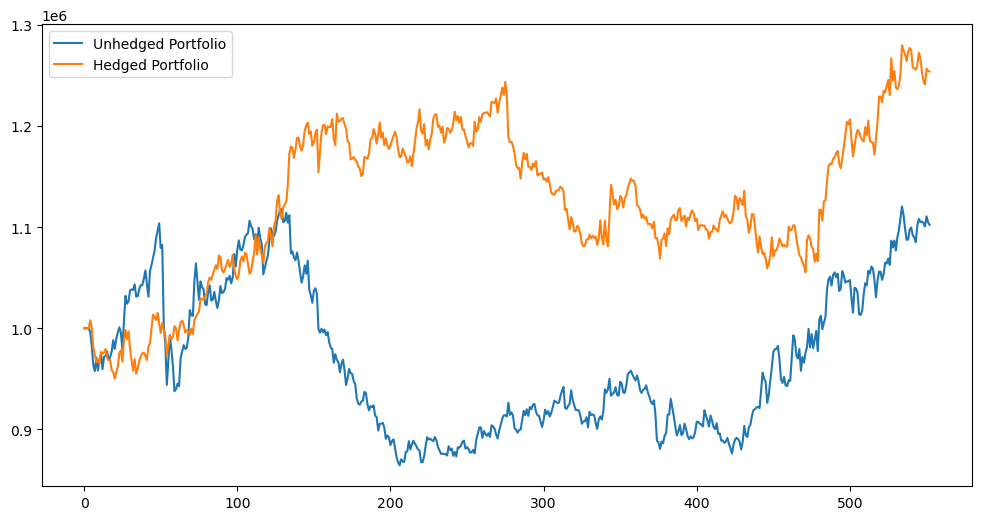

******BACKTEST METRICS******
Hedged Portfolio Returns: 25.38847281951904%
Unhedged Portfolio Returns: 10.234551934814453%
Hedged Portfolio Sharpe Ratio: 0.80439357825138
Unhedged Portfolio Sharpe Ratio: 0.35479127206215094


In [ ]:
stock1_portfolio = backtest(stock1,df,stock1_signals)
hedged_stock1_portfolio = hedged_backtest(stock1,hedge_stock1,df,stock1_signals)
stock2_portfolio = backtest(stock2,df,stock2_signals)
hedged_stock2_portfolio = hedged_backtest(stock2,hedge_stock2,df,stock2_signals)
final_portfolio = []
final_hedged_portfolio = []
for i in range(len(stock1_portfolio)):
  final_portfolio.append(stock1_portfolio[i] + stock2_portfolio[i])
  final_hedged_portfolio.append(hedged_stock1_portfolio[i] + hedged_stock2_portfolio[i])

plt.figure(figsize=(12,6))
plt.plot(final_portfolio,label='Unhedged Portfolio')
plt.plot(final_hedged_portfolio,label='Hedged Portfolio')
plt.legend()
plt.show()

print('******BACKTEST METRICS******')
print(f'Hedged Portfolio Returns: {(final_hedged_portfolio[-1] - final_hedged_portfolio[0])*100/final_hedged_portfolio[0]}%')
print(f'Unhedged Portfolio Returns: {(final_portfolio[-1] - final_portfolio[0])*100/final_portfolio[0]}%')
print(f'Hedged Portfolio Sharpe Ratio: {sharpe_ratio(pd.Series(final_hedged_portfolio).pct_change().dropna(),255,0)}')
print(f'Unhedged Portfolio Sharpe Ratio: {sharpe_ratio(pd.Series(final_portfolio).pct_change().dropna(),255,0)}')